#Demonstration: Multi-Model Sentiment Analysis Pipeline for Short Text

##Scenario

- A media analytics company named SentimentScope partners with streaming platforms and production studios to gauge audience reactions to movie and show releases. With hundreds of thousands of reviews coming in daily across platforms, they aim to automatically categorize the sentiment of user feedback into predefined labels like negative, somewhat negative, neutral, somewhat positive, and positive.

## 1. Importing Libraries

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import pickle
import warnings
warnings.filterwarnings('ignore')

# NLP Libraries
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Download NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

# Plot style
plt.style.use('ggplot')
sns.set(style='whitegrid')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


## 2. Load Datasets

In [2]:
train_data = pd.read_csv('train.csv', encoding='latin1')
test_data = pd.read_csv('test.csv', encoding='latin1')

print("Training data shape:", train_data.shape)
print("Test data shape:", test_data.shape)
display(train_data.head())

Training data shape: (27481, 10)
Test data shape: (4815, 9)


,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265,470.0,164
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,noon,60-70,Angola,32866272,1246700.0,26


## 3. Check for Missing Values

In [3]:
print("Missing values in training data:")
print(train_data.isnull().sum())
print("Missing values in test data:")
print(test_data.isnull().sum())

Missing values in training data:
textID              0
text                1
selected_text       1
sentiment           0
Time of Tweet       0
Age of User         0
Country             0
Population -2020    0
Land Area (Km²)     0
Density (P/Km²)     0
dtype: int64
Missing values in test data:
textID              1281
text                1281
sentiment           1281
Time of Tweet       1281
Age of User         1281
Country             1281
Population -2020    1281
Land Area (Km²)     1281
Density (P/Km²)     1281
dtype: int64


## 4. Unique Sentiment Classes

In [5]:
print("Sentiment Class Distribution:")
print(train_data['sentiment'].value_counts())

Sentiment Class Distribution:
sentiment
neutral     11118
positive     8582
negative     7781
Name: count, dtype: int64


## 5. Text Preprocessing Function

In [6]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(f"[{re.escape(string.punctuation)}]", "", text)
    text = re.sub(r'\d+', '', text)
    return text

## 6. Apply Cleaning

In [8]:
train_data['cleaned_text'] = train_data['text'].apply(clean_text)
test_data['cleaned_text'] = test_data['text'].apply(clean_text)

## 7. Stopwords and Lemmatization

In [11]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    words = word_tokenize(text)
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return ' '.join(words)

train_data['processed_text'] = train_data['cleaned_text'].apply(preprocess_text)
test_data['processed_text'] = test_data['cleaned_text'].apply(preprocess_text)

## 8. Train-Test Split

In [13]:
X = train_data['processed_text']
y = train_data['sentiment']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

## 9. TF-IDF Vectorization

In [14]:
tfidf = TfidfVectorizer(max_features=5000)
X_train_vec = tfidf.fit_transform(X_train)
X_val_vec = tfidf.transform(X_val)
X_test_vec = tfidf.transform(test_data['processed_text'])

## 10. Logistic Regression Model

In [15]:
lr = LogisticRegression()
lr.fit(X_train_vec, y_train)
y_pred_lr = lr.predict(X_val_vec)

## 11. SVM Model

In [16]:
svm = LinearSVC()
svm.fit(X_train_vec, y_train)
y_pred_svm = svm.predict(X_val_vec)

## 12. Naive Bayes Model

In [17]:
nb = MultinomialNB()
nb.fit(X_train_vec, y_train)
y_pred_nb = nb.predict(X_val_vec)

## 13. Random Forest Model

In [18]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_vec, y_train)
y_pred_rf = rf.predict(X_val_vec)

## 14. Evaluation Function

In [19]:
def evaluate_model(y_true, y_pred, model_name):
    print(f"\nModel: {model_name}")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("Classification Report:\n", classification_report(y_true, y_pred))

## 15. Evaluate All Models

In [20]:
evaluate_model(y_val, y_pred_lr, "Logistic Regression")
evaluate_model(y_val, y_pred_svm, "SVM")
evaluate_model(y_val, y_pred_nb, "Naive Bayes")
evaluate_model(y_val, y_pred_rf, "Random Forest")


Model: Logistic Regression
Accuracy: 0.6840094597052938
Confusion Matrix:
 [[ 922  542   98]
 [ 295 1655  280]
 [  52  470 1183]]
Classification Report:
               precision    recall  f1-score   support

    negative       0.73      0.59      0.65      1562
     neutral       0.62      0.74      0.68      2230
    positive       0.76      0.69      0.72      1705

    accuracy                           0.68      5497
   macro avg       0.70      0.68      0.68      5497
weighted avg       0.69      0.68      0.68      5497


Model: SVM
Accuracy: 0.6738220847735128
Confusion Matrix:
 [[ 973  468  121]
 [ 361 1510  359]
 [  76  408 1221]]
Classification Report:
               precision    recall  f1-score   support

    negative       0.69      0.62      0.65      1562
     neutral       0.63      0.68      0.65      2230
    positive       0.72      0.72      0.72      1705

    accuracy                           0.67      5497
   macro avg       0.68      0.67      0.68      5497

## 16. Visualize Confusion Matrix (Logistic Regression Example)

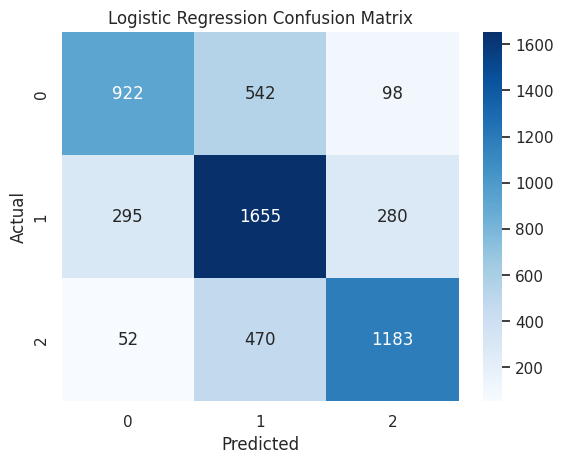

In [21]:
sns.heatmap(confusion_matrix(y_val, y_pred_lr), annot=True, cmap="Blues", fmt='d')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 17. Predict on Test Data using Best Model (example: SVM)

In [22]:
test_preds = svm.predict(X_test_vec)
test_data['Predicted_Sentiment'] = test_preds

## 18. Save to CSV

In [28]:
test_data[['text', 'Predicted_Sentiment']].to_csv('submission.csv', index=False)

## 19. Save Best Model

In [25]:
with open('best_sentiment_model.pkl', 'wb') as f:
    pickle.dump(svm, f)

## 20. Load Model Later

In [26]:
with open('best_sentiment_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

## 21. Predict Using Loaded Model

In [27]:
sample_text = ["This movie was absolutely fantastic!"]
sample_cleaned = [preprocess_text(clean_text(t)) for t in sample_text]
sample_vec = tfidf.transform(sample_cleaned)
print("Predicted Sentiment:", loaded_model.predict(sample_vec)[0])

Predicted Sentiment: positive
